In [1]:
!pip install -q -U transformers peft accelerate qwen-vl-utils
!pip install -q evaluate rouge_score sacrebleu scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 100.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 28.6 MB/s eta 0:00:0000:0100:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.2.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.9 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import torch
from transformers import set_seed
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    set_seed(seed) 

# Call this first!
seed_everything(42)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Qwen3VLForConditionalGeneration, 
    AutoProcessor, 
    TrainingArguments, 
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType
from qwen_vl_utils import process_vision_info
import evaluate
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# 1. SETUP PATHS

In [3]:
DATASET_DIR = '/kaggle/input/datasets/kaidegast/vqarad'  
IMG_DIR = os.path.join(DATASET_DIR, 'VQA_RAD Image Folder')
TRAIN_CSV = os.path.join(DATASET_DIR, 'vqa_rad_train.csv')
VAL_CSV = os.path.join(DATASET_DIR, 'vqa_rad_valid.csv')
TEST_CSV = os.path.join(DATASET_DIR, 'vqa_rad_test.csv')

# --- UPDATED: Using Qwen3-VL-2B-Instruct ---
BASE_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
OUTPUT_DIR = "./vqarad-qwen-final"

# Load Metrics
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

# 2. DATASET CLASS (Updated for Qwen Chat Template)

In [4]:
class VQARADDataset(Dataset):
    def __init__(self, csv_file, img_dir, processor, mode='train'):
        self.img_dir = img_dir
        self.processor = processor
        self.mode = mode
        self.data = pd.read_csv(csv_file)
        
        self.data['question'] = self.data['question'].astype(str)
        self.data['answer'] = self.data['answer'].astype(str)
        if 'answer_type' in self.data.columns:
            self.data['answer_type'] = self.data['answer_type'].astype(str).str.upper()
        else:
            self.data['answer_type'] = 'OPEN'

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_id = row['img_id']
        question = row['question']
        answer = row['answer']
        ans_type = row['answer_type']
        
        img_path = os.path.join(self.img_dir, img_id)
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='black')

        # --- Prompt Logic ---
        prompt_text = f"{question} Answer yes or no." if ans_type == 'CLOSED' else f"{question}"

        # 1. Define User Message
        user_message = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt_text},
                ],
            }
        ]

        if self.mode == 'train':
            # 2. Define Assistant Message
            assistant_message = [
                {"role": "assistant", "content": [{"type": "text", "text": answer}]}
            ]
            
            # 3. Generate Text for Prompt ONLY (to calculate mask length)
            text_prompt = self.processor.apply_chat_template(
                user_message, tokenize=False, add_generation_prompt=True
            )
            
            # 4. Generate Full Text (Prompt + Answer)
            full_conversation = user_message + assistant_message
            text_full = self.processor.apply_chat_template(
                full_conversation, tokenize=False, add_generation_prompt=False
            )
            
            # 5. Process Vision & Tokenize
            image_inputs, video_inputs = process_vision_info(full_conversation)
            
            inputs = self.processor(
                text=[text_full],
                images=image_inputs,
                videos=video_inputs,
                padding=False,
                return_tensors="pt",
            )
            
            # Squeeze batch dims
            inputs = {k: v.squeeze(0) for k, v in inputs.items()}
            
            # 6. Create Labels with MASKING
            # Tokenize just the prompt to find where the answer starts
            prompt_tokens = self.processor.tokenizer(
                text_prompt, return_tensors='pt', add_special_tokens=False
            )['input_ids'][0]
            
            prompt_len = len(prompt_tokens)
            
            # Create labels: clone input_ids, then set prompt tokens to -100
            labels = inputs['input_ids'].clone()
            labels[:prompt_len] = -100 
            
            # Important: Ensure padding tokens (if any exist implicitly) are also -100
            # (Though usually processor handles single items without padding)
            
            inputs['labels'] = labels
            return inputs

        else:
            # Validation/Test logic remains the same
            text = self.processor.apply_chat_template(user_message, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(user_message)
            
            inputs = self.processor(
                text=[text],
                images=image_inputs,
                videos=video_inputs,
                return_tensors="pt",
            )
            inputs = {k: v.squeeze(0) for k, v in inputs.items()}
            inputs['ground_truth'] = answer
            inputs['answer_type'] = ans_type
            return inputs

# 3. LOAD MODEL (Qwen3-VL-2B-Instruct Configuration)

In [5]:
print("--- Loading Qwen3-VL-2B-Instruct ---")

# Qwen uses AutoProcessor
processor = AutoProcessor.from_pretrained(BASE_MODEL_ID, min_pixels=256*28*28, max_pixels=1280*28*28)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID, 
    torch_dtype=torch.float16, # FP16 for P100
    device_map="auto",
    attn_implementation="eager", # P100 doesn't support FlashAttn2
)

# Enable gradient checkpointing to save memory
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# --- UPDATED: Qwen LoRA Config ---
peft_config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM", 
    # Qwen target modules are different from BLIP
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

--- Loading Qwen3-VL-2B-Instruct ---


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127


# 4. TRAINING

In [6]:
train_dataset = VQARADDataset(TRAIN_CSV, IMG_DIR, processor, mode='train')
eval_dataset = VQARADDataset(VAL_CSV, IMG_DIR, processor, mode='train')

def collate_fn(examples):
    tokenizer = processor.tokenizer
    
    # Extract lists
    input_ids = [e['input_ids'] for e in examples]
    labels = [e['labels'] for e in examples]
    
    # 1. Pad Inputs (Use tokenizer to handle left/right padding automatically)
    inputs_padded = tokenizer.pad(
        {"input_ids": input_ids},
        padding=True,
        return_tensors="pt"
    )
    
    # 2. Pad Labels
    # We treat labels as 'input_ids' just to use the pad function securely
    labels_padded = tokenizer.pad(
        {"input_ids": labels},
        padding=True,
        return_tensors="pt"
    )["input_ids"]
    
    # 3. Fix Label Padding
    # The tokenizer pads with `pad_token_id`, but we need `-100` for loss calculation
    labels_padded[labels_padded == tokenizer.pad_token_id] = -100

    # 4. Build Batch
    batch = {
        "input_ids": inputs_padded["input_ids"],
        "attention_mask": inputs_padded["attention_mask"],
        "labels": labels_padded,
    }

    # 5. Vision Tensors
    vision_keys = ['pixel_values', 'image_grid_thw', 'pixel_values_videos', 'video_grid_thw']
    for key in vision_keys:
        if key in examples[0] and examples[0][key] is not None:
            raw_tensors = [e[key] for e in examples]
            if 'grid_thw' in key:
                raw_tensors = [t.view(-1, 3) for t in raw_tensors]
            batch[key] = torch.cat(raw_tensors, dim=0)

    return batch

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=2, # Lower batch size for Qwen usually needed on P100
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    bf16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=1,
    report_to="none",
    logging_steps=5,
    remove_unused_columns=False, # Essential for Multimodal model
    dataloader_pin_memory=False  
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn
)

print("\n--- Starting Training ---")
trainer.train()
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)


--- Starting Training ---


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,7.415414,7.395936
2,7.433833,7.393245
3,7.507207,7.393077


['./vqarad-qwen-final/processor_config.json']

# 5. EVALUATION


   Running COMPREHENSIVE Evaluation on /kaggle/input/datasets/kaidegast/vqarad/vqa_rad_test.csv


100%|██████████| 225/225 [04:04<00:00,  1.09s/it]



RESULTS: CLOSED QUESTIONS (144 samples)
  Accuracy:                68.75%
  F1-Score (Weighted):     0.6928
  ROUGE-L:                 0.6875
  BLEU-2:                  0.8305

RESULTS: OPEN QUESTIONS (81 samples)
  Accuracy:                29.63%
  F1-Score (Weighted):     0.2804
  ROUGE-L:                 0.3998
  BLEU-2:                  0.1670

OVERALL DATASET RESULTS (225 samples)
  OVERALL Accuracy:        54.67%
  OVERALL ROUGE-L:         0.5828

>>> CONFUSION MATRIX (Closed-Ended: Yes vs No)


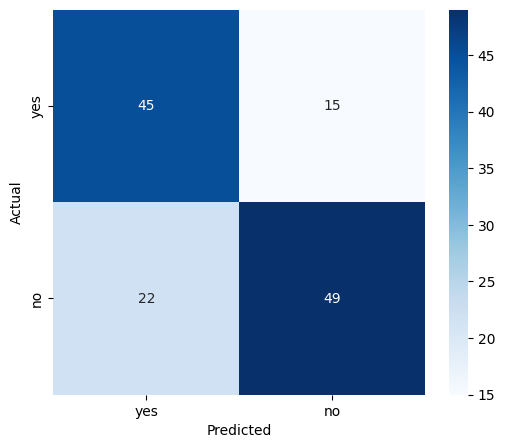

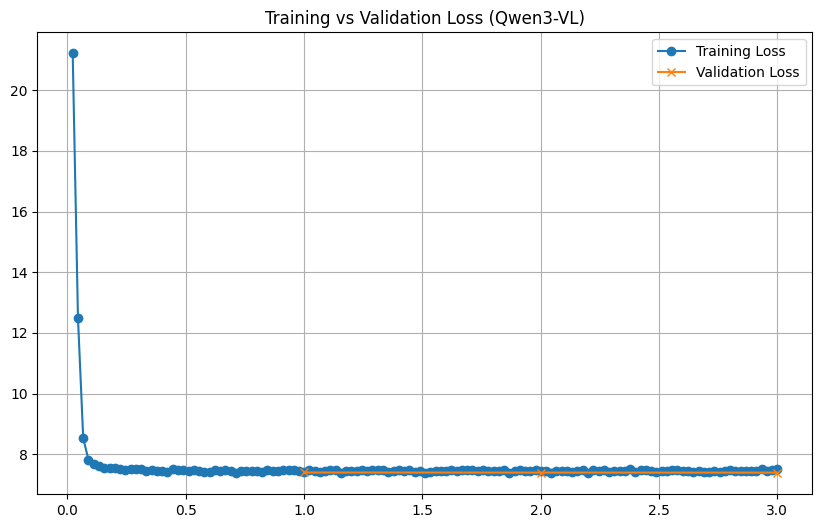

In [ ]:
import string
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def normalize_text(text):
    if not isinstance(text, str):
        return str(text)
    # Remove punctuation using translation table
    text = text.lower().strip().translate(str.maketrans('', '', string.punctuation))
    return text

def collate_fn(examples):
    tokenizer = processor.tokenizer
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id
        
    # Extract inputs
    input_ids = [example['input_ids'] for example in examples]
    attention_mask = [example['attention_mask'] for example in examples]
    
    # Dynamic Padding for Inputs
    padded_inputs = tokenizer.pad(
        {"input_ids": input_ids, "attention_mask": attention_mask},
        padding=True,
        return_tensors="pt"
    )
    
    batch = {
        "input_ids": padded_inputs["input_ids"],
        "attention_mask": padded_inputs["attention_mask"],
    }

    # Handle Labels (Only if they exist - Training Mode)
    if 'labels' in examples[0]:
        labels = [example['labels'] for example in examples]
        max_len = padded_inputs['input_ids'].shape[1]
        padded_labels = []
        for l in labels:
            pad_len = max_len - l.shape[0]
            if pad_len > 0:
                pad_tensor = torch.full((pad_len,), -100, dtype=l.dtype)
                # Pad consistent with tokenizer direction
                if tokenizer.padding_side == 'left':
                    padded_l = torch.cat([pad_tensor, l])
                else:
                    padded_l = torch.cat([l, pad_tensor])
            else:
                padded_l = l
            padded_labels.append(padded_l)
        batch["labels"] = torch.stack(padded_labels)

    # Handle Vision Inputs (Concatenate tensors)
    vision_keys = ['pixel_values', 'image_grid_thw', 'pixel_values_videos', 'video_grid_thw']
    for key in vision_keys:
        if key in examples[0] and examples[0][key] is not None:
            raw_tensors = [example[key] for example in examples]
            # Flatten grid_thw if needed
            if 'grid_thw' in key:
                raw_tensors = [t.view(-1, 3) for t in raw_tensors]
            batch[key] = torch.cat(raw_tensors, dim=0)

    # Preserve metadata for Evaluation (Keep as lists)
    if 'ground_truth' in examples[0]:
        batch['ground_truth'] = [ex['ground_truth'] for ex in examples]
    if 'answer_type' in examples[0]:
        batch['answer_type'] = [ex['answer_type'] for ex in examples]

    return batch

# ==========================================
# 3. DEFINE EVALUATION LOOP
# ==========================================
def run_full_metrics_evaluation(csv_path):
    print(f"\n=======================================================")
    print(f"   Running COMPREHENSIVE Evaluation on {csv_path}")
    print(f"=======================================================")
    
    # Load Dataset in Test Mode
    ds = VQARADDataset(csv_path, IMG_DIR, processor, mode='test')
    
    # CRITICAL: Batch size 1 is required for this specific eval logic 
    # because we pop [0] from the string lists
    loader = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
    
    model.eval()
    
    data = {"CLOSED": {"preds": [], "refs": []}, "OPEN": {"preds": [], "refs": []}}
    all_preds, all_refs = [], []
    
    for batch in tqdm(loader):
        # 1. Pop metadata (Strings) BEFORE moving to GPU
        # We use [0] because batch_size is 1
        ground_truth = normalize_text(batch.pop('ground_truth')[0])
        ans_type = batch.pop('answer_type')[0]
        
        # 2. Move remaining tensors to GPU
        device_batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        # 3. Generate
        with torch.no_grad():
            output_ids = model.generate(
                **device_batch,
                max_new_tokens=20,  # Cap response length
                do_sample=False     # Deterministic for eval
            )
        
        # 4. Decode
        # Slicing: remove the input tokens to get only the new generated tokens
        input_len = device_batch['input_ids'].shape[1]
        generated_ids = output_ids[:, input_len:]
        
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        pred = normalize_text(pred)
        
        # 5. Clean common Qwen chat artifacts
        # (Sometimes it repeats the instruction if the mask was wrong)
        if "answer yes or no" in pred:
            pred = pred.replace("answer yes or no", "").strip()
            
        # 6. Store Results
        if ans_type == 'CLOSED':
            data["CLOSED"]["preds"].append(pred)
            data["CLOSED"]["refs"].append(ground_truth)
        else:
            data["OPEN"]["preds"].append(pred)
            data["OPEN"]["refs"].append(ground_truth)
            
        all_preds.append(pred)
        all_refs.append(ground_truth)

    # ==========================================
    # 4. PRINT METRICS
    # ==========================================
    for category in ["CLOSED", "OPEN"]:
        preds, refs = data[category]["preds"], data[category]["refs"]
        if not preds: continue
        
        print(f"\nRESULTS: {category} QUESTIONS ({len(preds)} samples)")
        acc = accuracy_score(refs, preds)
        precision, recall, f1, _ = precision_recall_fscore_support(refs, preds, average='weighted', zero_division=0)
        
        # Wrapping refs in list for BLEU: [['yes'], ['no']]
        b2 = bleu_metric.compute(predictions=preds, references=[[r] for r in refs], max_order=2)
        rouge = rouge_metric.compute(predictions=preds, references=refs)

        print(f"  Accuracy:                {acc*100:.2f}%")
        print(f"  F1-Score (Weighted):     {f1:.4f}")
        print(f"  ROUGE-L:                 {rouge['rougeL']:.4f}")
        print(f"  BLEU-2:                  {b2['bleu']:.4f}")

    print(f"\nOVERALL DATASET RESULTS ({len(all_preds)} samples)")
    overall_acc = accuracy_score(all_refs, all_preds)
    overall_rouge = rouge_metric.compute(predictions=all_preds, references=all_refs)
    print(f"  OVERALL Accuracy:        {overall_acc*100:.2f}%")
    print(f"  OVERALL ROUGE-L:         {overall_rouge['rougeL']:.4f}")

    # Confusion Matrix (Closed Only)
    c_preds, c_refs = data["CLOSED"]["preds"], data["CLOSED"]["refs"]
    labels = ['yes', 'no']
    
    # Filter only valid yes/no responses for the plot
    final_refs, final_preds = [], []
    for r, p in zip(c_refs, c_preds):
        if r in labels and p in labels:
            final_refs.append(r)
            final_preds.append(p)
            
    if final_refs:
        print("\n>>> CONFUSION MATRIX (Closed-Ended: Yes vs No)")
        cm = confusion_matrix(final_refs, final_preds, labels=labels)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

# ==========================================
# 5. EXECUTE
# ==========================================
run_full_metrics_evaluation(TEST_CSV)

def plot_training_history(trainer):
    log_history = trainer.state.log_history
    train_epochs, train_losses = [], []
    val_epochs, val_losses = [], []

    for entry in log_history:
        if 'loss' in entry and 'epoch' in entry:
            train_epochs.append(entry['epoch'])
            train_losses.append(entry['loss'])
        if 'eval_loss' in entry and 'epoch' in entry:
            val_epochs.append(entry['epoch'])
            val_losses.append(entry['eval_loss'])

    plt.figure(figsize=(10, 6))
    if train_losses: plt.plot(train_epochs, train_losses, label='Training Loss', marker='o')
    if val_losses: plt.plot(val_epochs, val_losses, label='Validation Loss', marker='x')
    plt.title('Training vs Validation Loss (Qwen3-VL)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(trainer)